In [47]:
# ============================================
# CELL 1: Import required libraries
# ============================================

import numpy as np
import matplotlib.pyplot as plt


In [49]:
# ============================================
# CELL 2: Create a normal population
# ============================================

rng = np.random.default_rng(42)

N = 10000

# Normal population: mean = 50, std = 10
population = rng.normal(loc=50, scale=10, size=N)

population_mean = np.mean(population)

print("Population mean:", round(population_mean, 1))


Population mean: 49.9


In [50]:
# ============================================
# CELL 3: Create strata
# ============================================

# Define thresholds
low_threshold = 45
high_threshold = 55

# Create strata using logical indexing
stratum_low = population[population < low_threshold]
stratum_mid = population[(population >= low_threshold) & (population <= high_threshold)]
stratum_high = population[population > high_threshold]

print("Stratum sizes:")
print("Low:", len(stratum_low))
print("Mid:", len(stratum_mid))
print("High:", len(stratum_high))


Stratum sizes:
Low: 3075
Mid: 3895
High: 3030


In [51]:
# ============================================
# CELL 4: Stratified sampling
# ============================================

n = 300  # total sample size

# Proportional allocation
n_low = int(n * len(stratum_low) / N)
n_mid = int(n * len(stratum_mid) / N)
n_high = n - n_low - n_mid  # ensure total = n

# Random sampling within each stratum
sample_low = rng.choice(stratum_low, size=n_low, replace=False)
sample_mid = rng.choice(stratum_mid, size=n_mid, replace=False)
sample_high = rng.choice(stratum_high, size=n_high, replace=False)

# Combine
stratified_sample = np.concatenate([sample_low, sample_mid, sample_high])

sample_mean = np.mean(stratified_sample)

print("Stratified sample mean:", round(sample_mean, 3))


Stratified sample mean: 49.567


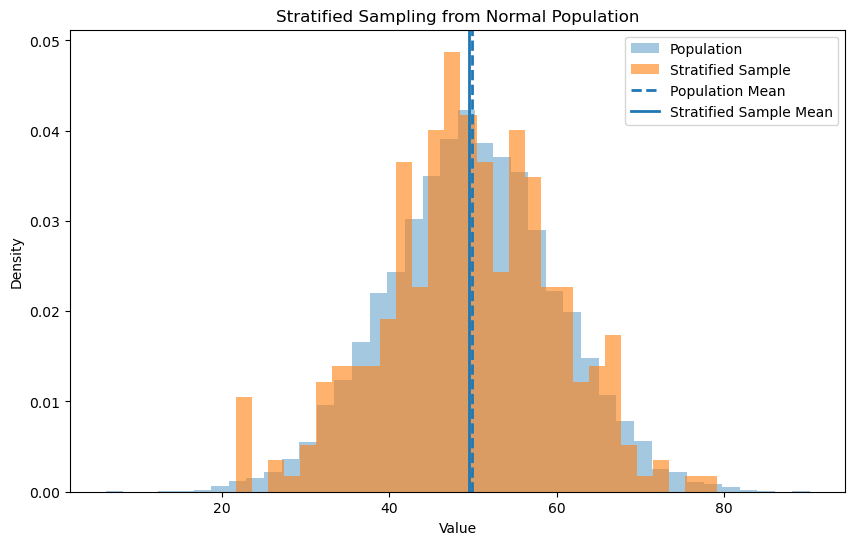

In [52]:
# ============================================
# CELL 5: Visualization
# ============================================

plt.figure(figsize=(10,6))

# Population histogram
plt.hist(population, bins=40, alpha=0.4, density=True, label="Population")

# Stratified sample histogram
plt.hist(stratified_sample, bins=30, alpha=0.6, density=True, label="Stratified Sample")

# Mean lines
plt.axvline(population_mean, linestyle='--', linewidth=2, label="Population Mean")
plt.axvline(sample_mean, linestyle='-', linewidth=2, label="Stratified Sample Mean")

plt.title("Stratified Sampling from Normal Population")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()
